Musculoskeletal / Trauma 

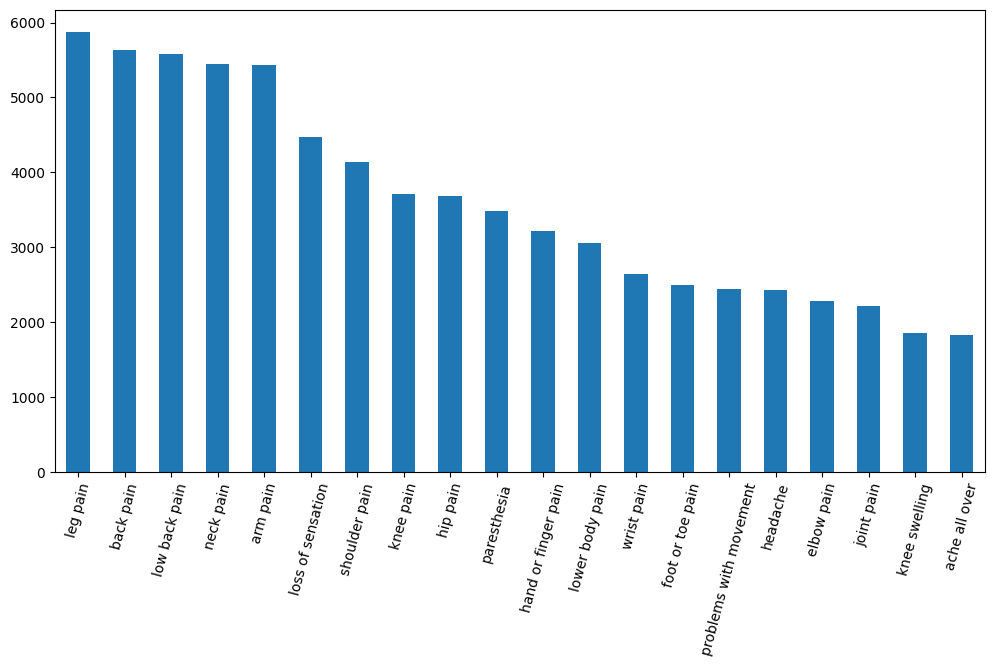

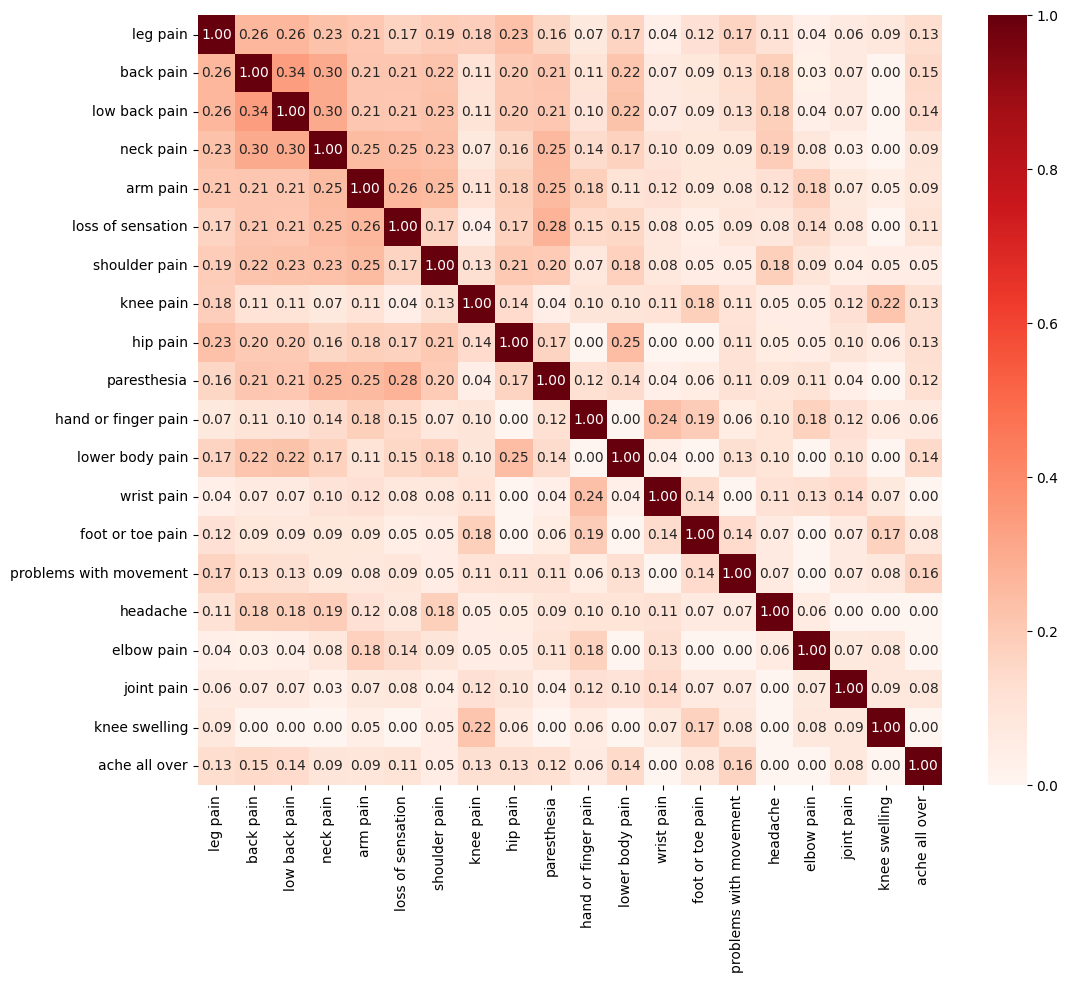

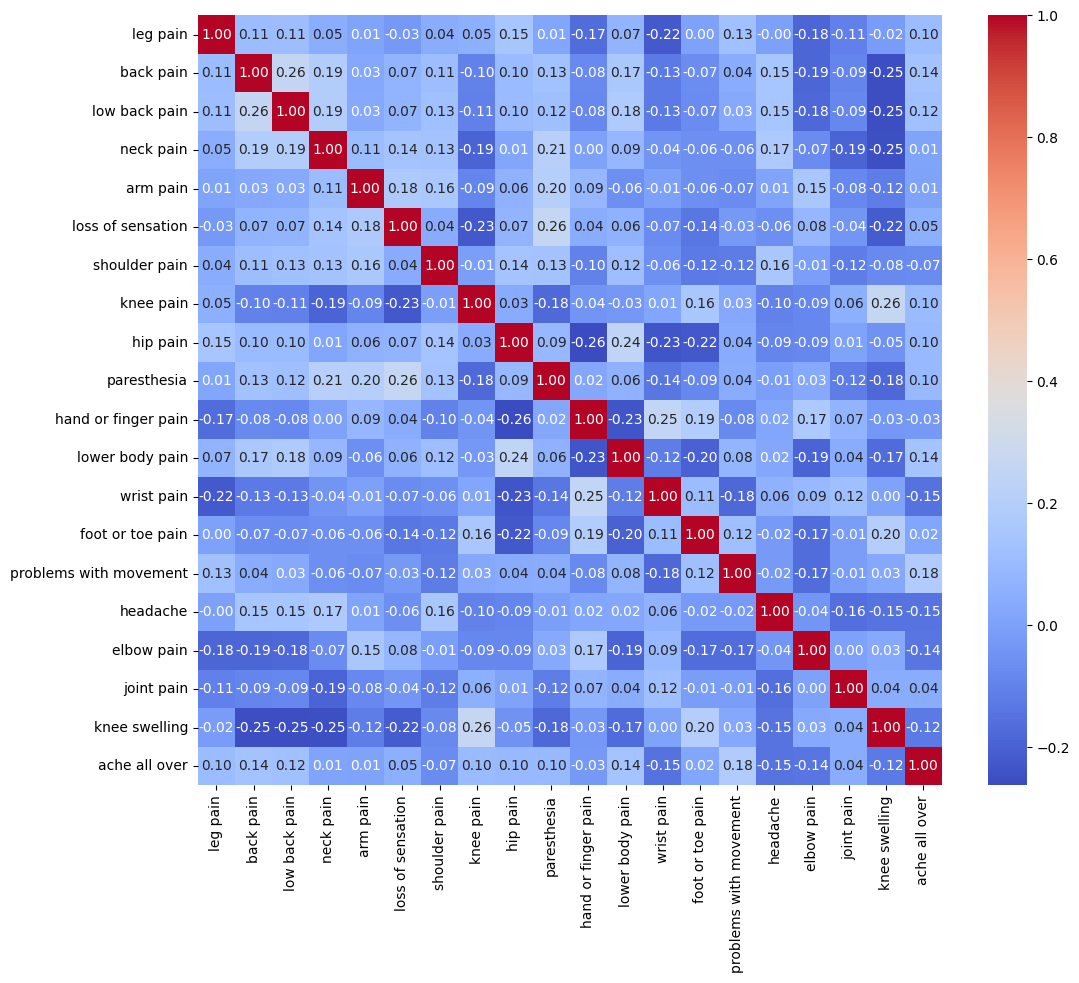

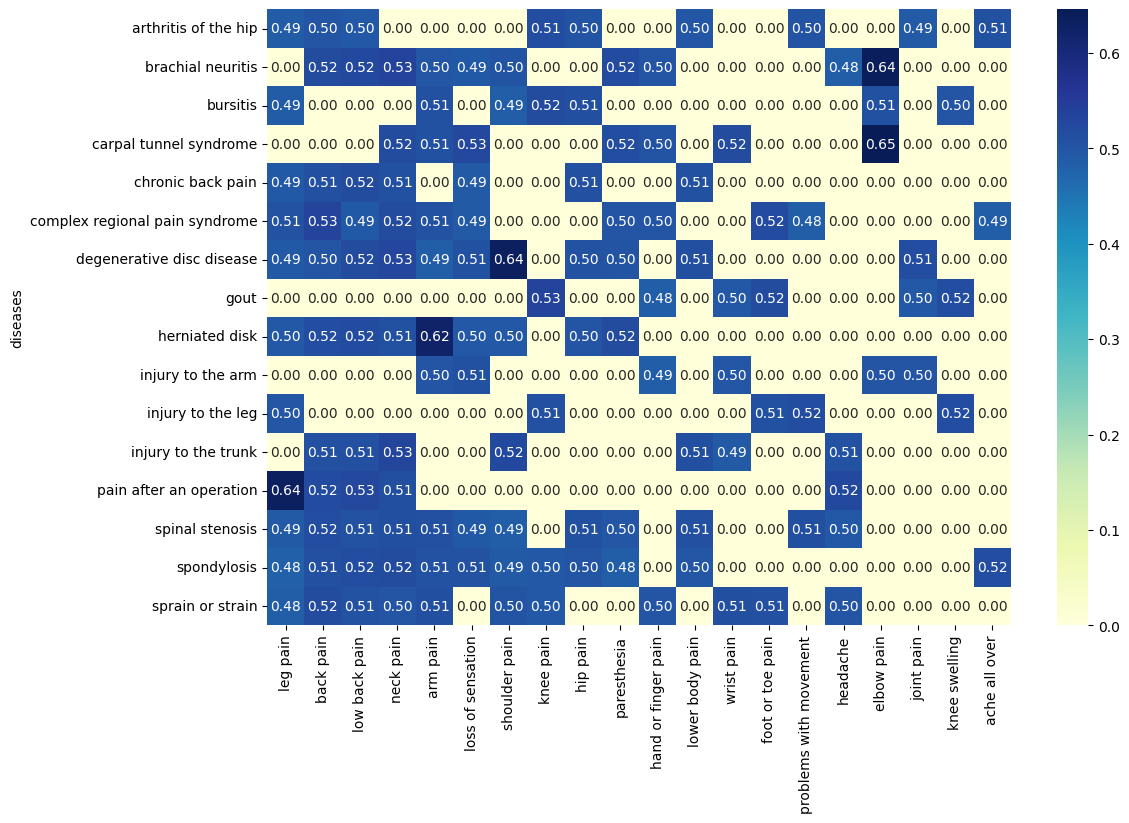

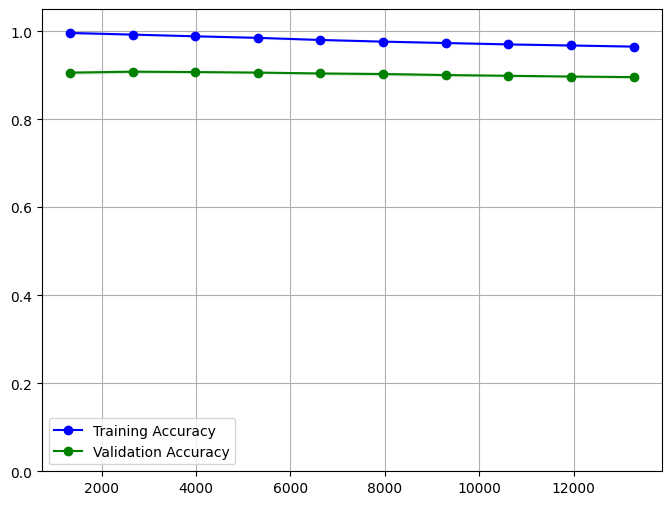

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import jaccard_score, classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

msk_diseases = [
    'bursitis', 'spondylosis', 'injury to the arm', 'complex regional pain syndrome',
    'injury to the trunk', 'degenerative disc disease', 'pain after an operation',
    'injury to the leg', 'carpal tunnel syndrome', 'arthritis of the hip',
    'spinal stenosis', 'sprain or strain', 'chronic back pain', 'herniated disk',
    'brachial neuritis', 'gout'
]

disease_col = 'diseases'
symptom_cols = [c for c in df.columns if c != disease_col]

df_msk = df[df[disease_col].isin(msk_diseases)]
selected_symptoms = df_msk[symptom_cols].sum()[lambda x: x>0].index.tolist()

X = df_msk[selected_symptoms]
y = df_msk[disease_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

symptom_counts = df_msk[symptom_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
symptom_counts.head(20).plot(kind='bar')
plt.xticks(rotation=75)
plt.show()

top_symptoms = symptom_counts.head(20).index.tolist()
jaccard_matrix = np.zeros((len(top_symptoms), len(top_symptoms)))
for i, s1 in enumerate(top_symptoms):
    for j, s2 in enumerate(top_symptoms):
        jaccard_matrix[i,j] = jaccard_score(df_msk[s1], df_msk[s2])

plt.figure(figsize=(12,10))
sns.heatmap(jaccard_matrix, xticklabels=top_symptoms, yticklabels=top_symptoms, cmap='Reds', annot=True, fmt=".2f")
plt.show()

corr_matrix = df_msk[symptom_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix.loc[top_symptoms, top_symptoms], cmap='coolwarm', annot=True, fmt=".2f")
plt.show()

disease_symptom_prob = df_msk.groupby(disease_col)[symptom_cols].mean()
plt.figure(figsize=(12,8))
sns.heatmap(disease_symptom_prob[top_symptoms], cmap='YlGnBu', annot=True, fmt=".2f")
plt.show()

models = {
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, learning_rate=0.3, n_estimators=500),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='ovr', C=1)
}

def plot_learning_curve(estimator, X, y, model_name):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Accuracy')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='green')
    plt.ylim(0,1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

for name, model in models.items():
    plot_learning_curve(model, X, y_encoded, name)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylim(0,1)
plt.show()
